# Peak and Pulse Finding experiments

In [1]:
from import_helper import *
import scipy.signal as scp


Loaded CONFIG {'udp_package_structure': {'udp_header_size_bytes': 4, 'snippet_header_size_bytes': 16, 'sample_size_bytes': 2, 'default_trace_length': 700}, 'struct_fields_mapping': {'UDP_header': {'Type': 'c', 'Number': 'B', 'Rest': '2s'}, 'Snippet_header': {'Channel_number': 'B', 'Trigger_info': 'B', 'Event_ID': 'H', 'Energy': '3s', 'Multiplicity': 'B', 'Subsecs': 'I', 'Seconds': 'I'}, 'Sample': 'h'}}
Device config Loaded config for utrfh from "c:\Users\utrfh\WS22-23 (MA) Masterarbeit\Codes\radc-processor\notebooks\../../nd-measurement-interfaces\user_config\utrfh_config.json"


In [2]:
list_imports()

data_io 	('data_parser.data_io',)
irrelevant_labels 	(['Type', 'Subsecs', 'Channel_number', 'Rest', 'min', 'max', 'trigger_count', 'Multiplicity', 'Trigger_info'],)
json 	('json',)
meas_base_path 	('C:/Users/utrfh/WS22-23 (MA) Masterarbeit/Measurements/',)
np 	('numpy',)
os 	('os',)
pGen_pulse_class 	('KeysightAgilent_3220A.pulse_emulation.pGen_pulse_class',)
path_to_data_parser 	('c:\\Users\\utrfh\\WS22-23 (MA) Masterarbeit\\Codes\\radc-processor\\notebooks\\..',)
path_to_meas_interfaces 	('c:\\Users\\utrfh\\WS22-23 (MA) Masterarbeit\\Codes\\radc-processor\\notebooks\\../../nd-measurement-interfaces/',)
pd 	('pandas',)
plotting 	('data_parser.plotting',)
plt 	('matplotlib.pyplot',)
pulse_emulation 	('KeysightAgilent_3220A.pulse_emulation',)
pyvisa 	('pyvisa',)
struct_conversion 	('data_parser.struct_conversion',)
sys 	('sys',)
types 	('types',)


In [3]:
meas = Measurement(
    # id = "BC230705c",
    id = "BC230705b",
    group_desc = "Shaper Statistics",
    # subgroup_desc = "FrequIncrement",
    subgroup_desc = "Test2",
    suffixes = ["65ns", "60mv", "stretch"],
    )

cdf = pd.read_pickle(meas.get_path("df", "save"))
print(cdf.shape)
print(cdf.index.unique("File"))
cdf.columns

New id: BC230705b_01-1_65ns_60mv_stretch
(261205, 17)
Index(['BC230705b_03-1_65ns_60mv_unstretched_readout.bin',
       'BC230705b_03-2_65ns_60mv_unstretched_readout.bin',
       'BC230705b_04-1_65ns_60mv_stretched_readout.bin',
       'BC230705b_04-2_65ns_60mv_stretched_readout.bin'],
      dtype='object', name='File')


Index(['Type', 'Number', 'Rest', 'Channel_number', 'Trigger_info', 'Event_ID',
       'Energy', 'Multiplicity', 'Subsecs', 'Seconds', 'min', 'max',
       'trigger_count', 'trigger_IDs', 'samples', 'Stretching', 'Triggering'],
      dtype='object')

In [4]:
# ex_samples = cdf.loc["BC230705c_02-1_65ns_60mv_unstretched_readout.bin.1"]["samples"]
ex_samples = cdf.loc["BC230705b_03-1_65ns_60mv_unstretched_readout.bin"]["samples"]

def find_peaks(x):
    # print(x)
    return scp.find_peaks(
        x,
        height=800, # Absolute minimal value of the peak sample value.
        threshold=None,  # minimum right and left difference between the single peak sample and its neighbours.
        distance=None,  # minimum required distance between neighbouring peaks
        prominence=800, # Difference between highest point and lowest contour line. Returns sample indices
        width=1,    # Interpolated peak width in samples at given rel_height
        wlen=14,    # Window length of area to inspect, centered around peak, to determine prominence and width. Cuts signal at those limits.
        rel_height=0.5, # Relative height at which peak width is measured (% of its prominence). 1.0: width of the peak at lowest contour line. 0.5: evaluates at half the prominence height.
        plateau_size=None   # Minimum required width in samples of peak's flat top.
        )

print(ex_samples.iloc[0])
# print(json.dumps(ex_samples.apply(find_peaks)[0], indent=4, cls=CustomEncoder))
peaks = ex_samples.apply(find_peaks)
print(peaks[0])
peaks

[-5, -3, -4, -3, -4, -2, -2, -1, -2, -3, -2, -3, -2, -1, -4, -3, -5, -4, -2, -4, -3, -3, -3, -5, 6, 196, 714, 1068, 857, 448, 174, 52, 12, 3, 0, 1, 0, 0, -2, 0, -2, -2, -4, -2, -3, -2, -2, -2, -4, -3, -2, -2, -5, -2, -2, -3, -2, -1, -1, -1, -2, -2, -3, -3, 0, 0, -3, -1, 0, -2, -2, -3, -2, -2, -2, -1, -1, -1, -2, -3, -4, -3, -2, -2, -3, -2, -1, -2, -2, -5, -5, -4, -2, -3, -4, -2, 0, -3, -1, 0]
(array([27], dtype=int64), {'peak_heights': array([1068.]), 'prominences': array([1068.]), 'left_bases': array([23], dtype=int64), 'right_bases': array([34], dtype=int64), 'widths': array([3.1372214]), 'width_heights': array([534.]), 'left_ips': array([25.65250965]), 'right_ips': array([28.78973105])})


Event
0         ([27], {'peak_heights': [1068.0], 'prominences...
1         ([16], {'peak_heights': [1063.0], 'prominences...
2         ([15], {'peak_heights': [1065.0], 'prominences...
3         ([15], {'peak_heights': [1050.0], 'prominences...
4         ([15], {'peak_heights': [1015.0], 'prominences...
                                ...                        
184837    ([27], {'peak_heights': [1066.0], 'prominences...
184838    ([27], {'peak_heights': [1067.0], 'prominences...
184839    ([26], {'peak_heights': [1006.0], 'prominences...
184840    ([27], {'peak_heights': [1036.0], 'prominences...
184841    ([26], {'peak_heights': [1010.0], 'prominences...
Name: samples, Length: 184823, dtype: object

In [5]:
def get_peak_count(x):
    return len(x[0])

peaks.apply(get_peak_count).value_counts()

samples
1    184823
Name: count, dtype: int64

`find_peaks` returns an `ndarray`:
```json
[
    [28],
    {
        "peak_heights": [1049.0],
        "prominences": [1045.0],
        "left_bases": [21],
        "right_bases": [37],
        "widths": [3.158415259178934],
        "width_heights": [526.5],
        "left_ips": [26.80857740585774],
        "right_ips": [29.966992665036674]
    }
]
```
Each entry contains an array of values, sorted by the order of peaks given in the first element. The values are mostly interpolated ones.

-  `height=800`, Absolute minimal value of the peak sample value.
    - Returns `peak_heights`.
-  `threshold=None`, minimum right and left difference between the single peak sample and its direct neighbours.
    - Returns `left_thresholds`, `right_thresholds`.
-  `distance=None`, minimum required distance between neighbouring peaks
    - Returns nothing.
-  `prominence=800`, Difference between highest point and lowest contour line. Returns sample indices
    - Returns `prominences`,
    - `left_bases`
    - and `right_bases`.
-  `width=1`, Interpolated peak width in samples at given `rel_height`
    - Returns `widths`,
    - `widths_heights`,
    - `left_ips` (interpolated positions of left and right intersection points of a horizontal line at the respective evaluation height),
    - `right_ips`.
-  `wlen=20`, Window length of area to inspect, centered around peak, to determine prominence and width. Cuts signal at those limits.
    - Returns Nothing.
-  `rel_height=0.5`, Relative height at which peak width is measured (% of its prominence). 1.0: width of the peak at lowest contour line. 0.5: evaluates at half the prominence height.
    - Returns nothing, but it prescribes `widths_heights`. 
-  `plateau_size=None` Minimum required width in samples of peak's flat top.
    - Returns `plateau_sizes`, `left_edges`, `right_edges`.

## Integration

23 34


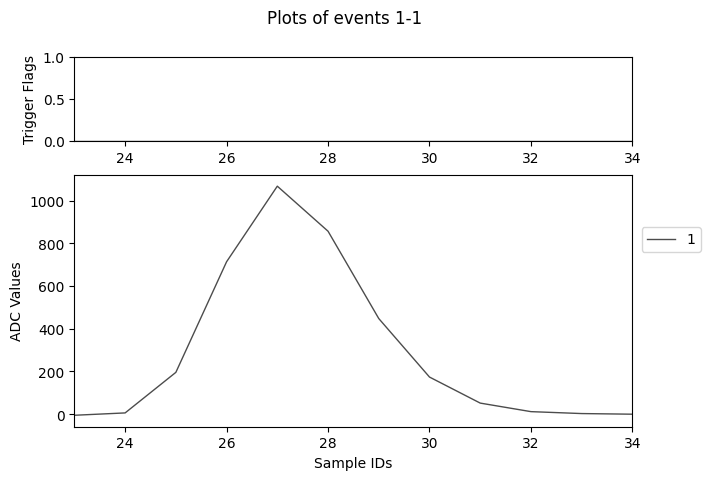

In [27]:
blah = plotting.plot_rows(
    # cdf.loc["BC230705c_02-1_65ns_60mv_unstretched_readout.bin.1"].iloc[:1],
    cdf.loc["BC230705b_03-1_65ns_60mv_unstretched_readout.bin"].iloc[:1],
    xlim=[
        peaks[0][1]["left_bases"][0],
        peaks[0][1]["right_bases"][0],
    ]
    )

print(peaks[0][1]["left_bases"][0], peaks[0][1]["right_bases"][0])

# plotting.plot_rows(
#     # cdf.loc["BC230705c_02-1_65ns_60mv_unstretched_readout.bin.1"],
#     cdf.loc["BC230705b_03-1_65ns_60mv_unstretched_readout.bin"],
#     xlim=[
#         min([i[1]["left_bases"][0] for i in peaks]),
#         max([i[1]["right_bases"][0] for i in peaks]),
#     ]
#     )

In [7]:
files = cdf.index.unique("File")
files

Index(['BC230705b_03-1_65ns_60mv_unstretched_readout.bin',
       'BC230705b_03-2_65ns_60mv_unstretched_readout.bin',
       'BC230705b_04-1_65ns_60mv_stretched_readout.bin',
       'BC230705b_04-2_65ns_60mv_stretched_readout.bin'],
      dtype='object', name='File')

In [12]:

cdf["PeakFinding"] = cdf["samples"].apply(
    scp.find_peaks,
    height=150, # Absolute minimal value of the peak sample value.
    prominence=100, # Difference between highest point and lowest contour line. Returns sample indices
    width=1,    # Interpolated peak width in samples at given rel_height
    wlen=14,    # Window length of area to inspect, centered around peak, to determine prominence and width. Cuts signal at those limits.
    rel_height=0.5, # Relative height at which peak width is measured (% of its prominence). 1.0: width of the peak at lowest contour line. 0.5: evaluates at half the prominence height.
)
cdf["PeakFinding"]

File                                              Event
BC230705b_03-1_65ns_60mv_unstretched_readout.bin  0        ([27], {'peak_heights': [1068.0], 'prominences...
                                                  1        ([16], {'peak_heights': [1063.0], 'prominences...
                                                  2        ([15], {'peak_heights': [1065.0], 'prominences...
                                                  3        ([15], {'peak_heights': [1050.0], 'prominences...
                                                  4        ([15], {'peak_heights': [1015.0], 'prominences...
                                                                                 ...                        
BC230705b_04-2_65ns_60mv_stretched_readout.bin    73458    ([27], {'peak_heights': [197.0], 'prominences'...
                                                  73459    ([27], {'peak_heights': [200.0], 'prominences'...
                                                  73460    ([27], {'peak

In [26]:
print(cdf["PeakFinding"].apply(get_peak_count).value_counts())
problematic = cdf[cdf["PeakFinding"].apply(get_peak_count) == 0]
print(problematic.shape)
if problematic.shape[0] > 0:
    blah = plotting.plot_rows(problematic)


PeakFinding
1    261205
Name: count, dtype: int64
(0, 20)


In [14]:
def get_limits(x):
    # first, assume only one peak per row of samples
    return x[1]["left_bases"][0], x[1]["right_bases"][0]

def add_samples(x):
    return sum(x["samples"][x["Limits"][0]:x["Limits"][1]+1])

cdf["Limits"] = cdf["PeakFinding"].apply(get_limits)

# sums = cdf[["samples", "Limits"]].apply(lambda x: add_samples(x["samples"]))
cdf["Sum"] = cdf[["samples", "Limits"]].apply(add_samples, axis=1)

3424 3584
3503.916789514165 19.606091126340694 0.5595478518500769


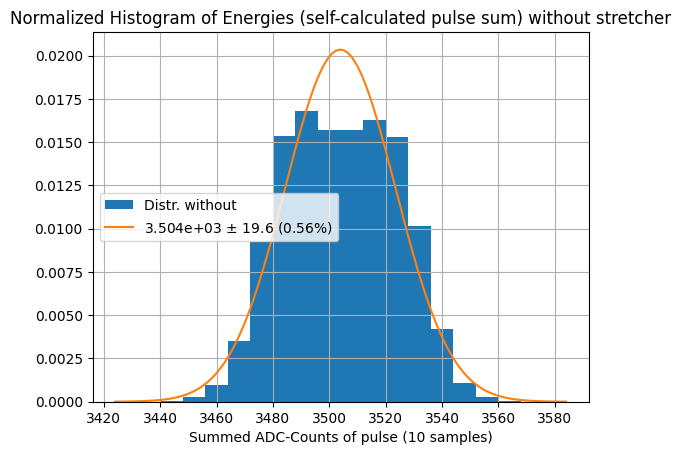

897 975
934.7219015693219 8.754767562964624 0.9366173562710024


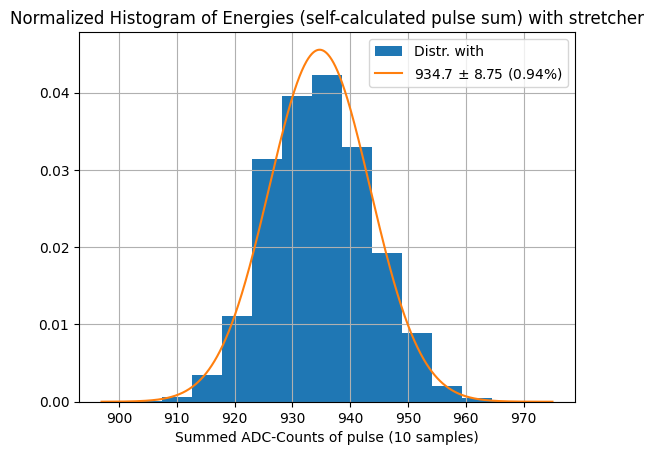

In [21]:
import scipy 
def plot_distribution_histogram(data, withs, nbins=15):
    data.hist(bins=nbins, density=True, label=f"Distr. {withs}")

    x_array = np.linspace(min(data), max(data), 1000)

    mean, sigma = scipy.stats.norm.fit(data)
    pct = 100*sigma/mean
    fit_line = scipy.stats.norm.pdf(x_array, mean, sigma)

    plt.title(f"Normalized Histogram of Energies (self-calculated pulse sum) {withs} stretcher")
    plt.plot(
        x_array, fit_line,
        label=f"{mean:.4} $\pm$ {sigma:.3} ({pct:.2}%)"
        )
    plt.xlabel("Summed ADC-Counts of pulse (10 samples)")
    plt.legend()
    print(min(data), max(data))
    print(mean, sigma, pct)
    return (mean, sigma), plt.gcf()


data_stretched = cdf[cdf["Stretching"] == "stretched"]["Sum"]
data_unstretched = cdf[cdf["Stretching"] == "unstretched"]["Sum"]

unstretch, unst_plot = plot_distribution_histogram(data_unstretched, "without", nbins=20)
plt.show()
stretched, stre_plot = plot_distribution_histogram(data_stretched, "with")